# Exact Sparse $\ell_0$ Nonnegative Least Squares

:::{admonition} Reference
:class: tip
{cite:p}`nadisicExactSparseNonnegative2020` N. Nadisic, J. E. Cohen, A. Vandaele, N. Gillis, "Exact Sparse Nonnegative Least Squares", ICASSP2020, [pdf](https://hal.archives-ouvertes.fr/hal-02634895) 
:::

Throughout this manuscript, the reader encounters many instances of the Nonnegative Least Squares problem (NNLS). Indeed, as soon as regularized Low-Rank Approximations are considered with the Euclidean norm as a distance metric and nonnegativity, NNLS or related variants are required to update the parameter matrices in an alternating fashion. Therefore, efficient solvers for NNLS, in particular with matrix unknowns and warm-start, are instrumental to designing efficient algorithms for nonnegative LRA. Recall a generic formulation of (matrix) NNLS as follows,

$$ \underset{V\in\mathbb{R}_+^{r\times n}}{\min} \|Y - UV^T\|_F^2 $$
with $Y\in\mathbb{R}^{m\times n}$ the input data matrix, and $U\in\mathbb{R}^{m\times r}$ the mixing matrix, which may both in principle have positive and negative entries. The reader may refer to the [dedicated section regarding NNLS](../../part1/nnls.md) in the first part of this manuscript.

An important variant of NNLS is the sparse NNLS problem (sNNLS), in which the coefficients are constrained to have only a few nonzero entries. In the following, we assume this sparsity is enforced columnwise on matrix $V^T$, although we have also worked on a sparsity constraint applied on all entries of $V^T$ {cite:p}`nadisic_matrixwise_2022`, not discussed in this manuscript. Columnwise sparsity on the coefficient matrix $V^T$ is frequently encountered in applications of rLRA related to source separation. For instance, the matrix $V^T$ may denote source activations in a mixture; it is often reasonable to assume that not all sources are activated at all times or positions. We give examples below in remote sensing spectral unmixing and audio automatic transcription [TODO check]. The (matrix) sNNLS problem can be formulated as


$$ \underset{V\in\mathbb{R}_+^{n\times r}}{\min} \|Y - UV^T\|_2^2 \;\; \text{such that } \;\; \forall q\leq n,\; \|V[q,:]\|_0\leq k $$
for a known fixed sparsity level $k<r$.

Note that, unlike matrix NNLS, for which we can design algorithms using matrix-matrix products which leverage the native parallelism of these operations, when solving matrix sNNLS globally, we have not found a better solution than applying a vector sNNLS solver in a loop over all columns. Therefore, we may simply study the following (vector) sNNLS problem,

$$ \underset{v\in\mathbb{R}_+^{r}}{\min} \|y - Uv\|_2^2 \;\; \text{such that } \;\; \|v\|_0\leq k $$ (sNNLS)
with $y$ a column of input matrix $Y$ and $v$ a column of matrix $V^T$.

Geometrically, sNNLS is the projection of a data vector $y$ on the facets of the cone spanned by columns of $U$.

[illustration with r=3 and k=2 ? in 3d, with $U$ positive ?]

## sNNLS is NP-hard, but the rank is typically small

Looking at sNNLS {eq}`sNNLS`, the reader may recognize a particular case of the sparse coding problem with nonnegativity constraints. In fact if we could solve sNNLS in polynomial time of $r$, we could solve sparse coding with the same time complexity since a sparse matrix-vector product $Ax$ can be rewritten as a sparse nonnegative matrix-vector product $[A,-A][x_{+}, x_{-}]$ splitting the positive and negative parts of sparse vector $x$. This proves that sNNLS is NP-hard. Computing global solutions to sparse coding is therefore bound to be expensive when the dimension $r$ grows.

Nevertheless, in rLRA problems, dimension $r$ refers to the rank of the rLRA model, which is typically reasonably small. This opens the door to considering algorithms that explore the entire set of solutions. Indeed, the sNNLS problem reduces to finding an optimal support for the solution $v^\ast$, since


$$ \underset{v\in\mathbb{R}_+^{r}}{\min} \|y - Uv\|_2^2 \;\; \text{such that} \;\; \|v\|_0\leq k \; =
  \underset{\#S\leq k,\; S\subset[1,r]}{\min} ~\underset{v_S\in\mathbb{R}_+^{k}}{\min} \|y - U[:,S]v_S\|_2^2$$ (split_sNNLS)
  where the inner problem wrt. $v_S$ is a simple NNLS of reduced dimension.

## Branch and Bound strategy

Considering equation {eq}`split_sNNLS`, we could solve the (vector) sNNLS problem by computing $r \choose k$ NNLS problems of size $k$. This brute force approach is tractable for small $k$ and $r$ and has the advantage of computing the global solution to sNNLS. Nevertheless, let us consider a more subtle approach that still solves sNNLS globally.

The key observation is that the cost function $\|y - Uv\|_2^2$ is necessarily larger at the optimal solution when the variable $v$ is more constrained. Formally, if $S_1 \subset S_2 \subset [1,r]$ are two supports with $S_1$ strictly included in $S_2$ (corresponding to a sparser solution $v^\ast_1$), then

$$ \underset{v\geq 0}{\min} \|y - U[:, S_1]v\|_2^2 \geq \underset{v\geq 0}{\min} \|y - U[:, S_2]v\|_2^2. $$

In other words, the optimal cost necessarily increases as the constraint set grows. This observation suggests a Branch-and-Bound (BaB) algorithm for searching the combinatorial space of supports. We may first compute a guess for the optimal sNNLS solution using a heuristic algorithm, such as Nonnegative Orthogonal Matching Pursuit {cite:p}`Pati1993Orthogonal`. The cost function value at this solution $v_{\text{UB}}$ is an upper bound UB of the actual minimal cost of $k$-sparse sNNLS. Second, we may compute all NNLS problems with one zero element. For illustration purposes, consider the problem where the first element in $v$ is set to zero, and denote the optimal cost for this problem $s^\ast$. Because of the previous observation regarding monotonicity of the costs with increasing constraints, cost $s^\ast$ is a lower bound LB on the optimal costs of all subsequent sNNLS problems, including the constraint that the first element is zero. This fact applies to any set of constraints (any node in the tree of possible supports, see illustration below). The BaB algorithm allows us to save computation time when we encounter the case $UB<LB$, in which case we know that the current proposed solution $v_{\text{UB}}$ will always be better than all possible solutions, including the constraints of the node at LB. We say that BaB then prunes the node and its children, where $LB$ was computed. Importantly, when a new solution for an $r$-sparse NNLS problem is computed, if its loss is lower than the current UB, we have obtained a new tighter UB, and update $v_{\text{UB}}$ and UB accordingly. This procedure is perhaps better understood using a tree visualisation, see below.

[TODO figure gif with graph pruning, r=4, k=2]

We named the proposed BaB algorithm for solving sNNLS `arborescent`.

```{note}
Despite the BaB algorithm pruning nodes, thus avoiding some computations, the total number of nodes in the graph -- and therefore the total number of NNLS problems to solve if no pruning is achieved -- is $\sum_{p=k}^{r} {r\choose p}$. Therefore in some problem instances, the brute force algorithm can be faster if well implemented.
```

```{note}
The proposed arborescent algorithm, in fact, solves all $p$-sparse NNLS problems for $p\geq k$. Indeed, one can show that the tree obtained after running arborescent can be cut at any floor optimally. This is useful if the sparsity level is not known in advance, in which case arborescent returns all $p$-sparse solutions.
```

### A few details on the actual computations

**Upper bound.** We compute a full NNLS at the root node, sort the coefficients, prune the smallest ones, and then recompute the resulting $r$-sparse sNNLS. This is equivalent to a depth‑first, left‑first exploration of the search tree. The nodes are then explored left to right (with the largest initial nonnegative coefficients first).

**NNLS solver.** To avoid spending too much time in the NNLS solver at each node, we use a warm start with the active‑set algorithm run to global convergence. In this setting, warm starts are extremely effective, drastically reducing computation time while keeping an exact solver and avoiding errors from early stopping.

**Implementation.** The method is implemented in Julia because loops and recursion are efficiently compiled.

## Examples of matrix sparse Nonnegative Least Squares



In [ ]:
import tensorly as tl
from tensorly.datasets import data_imports
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tensorly_hdr.sep_nmf import snpa
from tensorly_hdr.giantly.arborescent import ksparse_nnls
from tensorly.solvers.nnls import hals_nnls

# Import an hyperspectral image
image_bunch = data_imports.load_indian_pines()
image_t = image_bunch.tensor # x by y by wavelength
image_t = image_t/tl.max(image_t) # maximum value set to 1
# Vectorize the tensor into a n_1\times n_2 matrix (wavelength \times pixels, y vary first)
image = tl.unfold(image_t, 2)

# Indian Pines is 145 by 145 (pixels) by 200 (bands)
n1, n2, n3 = tl.shape(image_t)
rank = 5

# select pure pixels and compute dense abundances
_, U, VTdense = snpa(image, rank)

# compute k sparse coefficients with sNNLS
VTsparse = tl.copy(VTdense)
imagetimage = tl.norm(image, axis=0)**2
k = 2

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
/home/cohen/Travail/Ecriture-Projets/HDR/manuscript/tensorly_hdr/tensorly_hdr/giantly


In [ ]:
VTsparse = ksparse_nnls(U.T@image, U.T@U, imagetimage, VTsparse, k)

We can also implement a bare-bones alternating algorithm for NMF with k-sparse coefficients as follows. This algorithm is guaranteed to converge since it is an exact alternating algorithm with unique and attained subproblem solutions (supposing full-rank factors at each iteration), see [](../../part1/AlternatingOptimization.md).

In [ ]:
def barebone_aNNLS_sNMF(Y, U, VT, rank, k, itermax=10, tol=1e-8):
    # inplace modification of initial U and V
    YtY = tl.norm(image, axis=0)**2
    for i in range(itermax):
        print(f"Running iteration {i}")
        VT = ksparse_nnls(U.T@image, U.T@U, YtY, VT, k) # r x n1n2
        U = hals_nnls(VT@image.T, VT@VT.T, U.T).T
        rmse = tl.norm(Y - U@VT)/tl.sqrt(n1*n2*n3)
        print(f"RMSE is {rmse}")
        if rmse<tol:
            break
    return U, VT

Usnmf, VTsnmf = barebone_aNNLS_sNMF(image, tl.copy(U), tl.copy(VTdense), rank, k)
# Clustering with k=1
Usnmf1, VTsnmf1 = barebone_aNNLS_sNMF(image, tl.copy(U), tl.copy(VTdense), rank, 1)

Running iteration 0
RMSE is 0.013592258206363285
Running iteration 1
RMSE is 0.012696440458471936
Running iteration 2
RMSE is 0.012601905548613422
Running iteration 3
RMSE is 0.012567772923926707
Running iteration 4
RMSE is 0.01254075956151307
Running iteration 5
RMSE is 0.012514251533131546
Running iteration 6
RMSE is 0.012481050200018422
Running iteration 7
RMSE is 0.012433165425742281
Running iteration 8
RMSE is 0.012383880798755416
Running iteration 9
RMSE is 0.012360165697365408
Running iteration 0
RMSE is 0.023704230429043564
Running iteration 1
RMSE is 0.02192505747529786
Running iteration 2
RMSE is 0.02143724830285735
Running iteration 3
RMSE is 0.021338320710414374
Running iteration 4
RMSE is 0.021307224402818143
Running iteration 5
RMSE is 0.021277418334322652
Running iteration 6
RMSE is 0.02122657696923403
Running iteration 7
RMSE is 0.02111729906887571
Running iteration 8
RMSE is 0.0206585116377421
Running iteration 9
RMSE is 0.019657966506385138


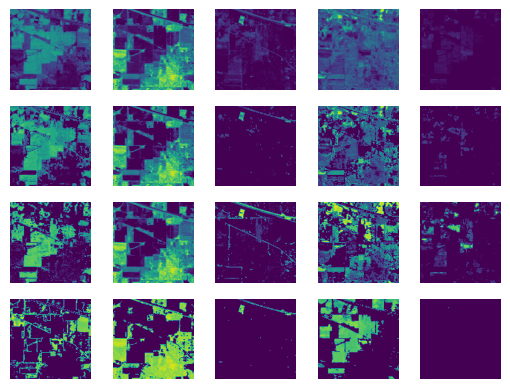

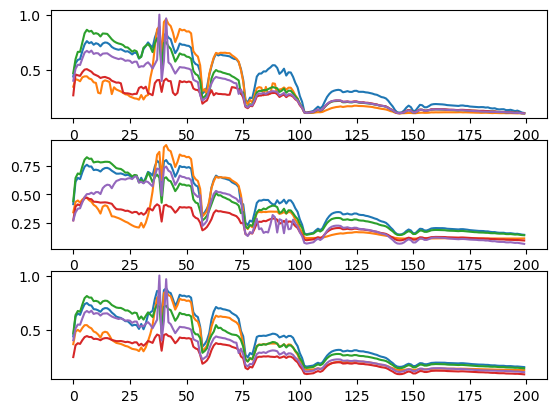

In [ ]:
fig, axs = plt.subplots(4, rank)
for i in range(rank):
    axs[0, i].imshow(tl.reshape(VTdense[i,:], [n1, n2]))
    axs[0, i].set_axis_off()
    axs[1, i].imshow(tl.reshape(VTsparse[i,:], [n1, n2]))
    axs[1, i].set_axis_off()
    axs[2, i].imshow(tl.reshape(VTsnmf[i,:], [n1, n2]))
    axs[2, i].set_axis_off()
    axs[3, i].imshow(tl.reshape(VTsnmf1[i,:], [n1, n2]))
    axs[3, i].set_axis_off()

fig2, ax2 = plt.subplots(3, 1)
ax2[0].plot(U)
ax2[1].plot(Usnmf)
ax2[2].plot(Usnmf1)
plt.show()